In [33]:
import numpy as np
import json
from tqdm import tqdm
import polars as pl
from matplotlib import pyplot as plt

In [63]:
with open(
    "/home/dangnh36/datasets/ecg/processed/reference_keypoints.json", "r"
) as f:
    ref_kpts = json.load(f)
ref_kpt_xys = np.array(list(ref_kpts.values()))
ref_kpt_names = list(ref_kpts.keys())
len(ref_kpt_names), ref_kpt_xys.shape

(2422, (2422, 2))

In [64]:
pred_kpt_xys = np.load('/home/dangnh36/datasets/ecg/processed/pseudo_label/round2_finetune_dsnt/keypoints_by_round2.npy')
pred_kpt_xys.shape

(8793, 2422, 2)

In [65]:
df = pl.read_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_round2.csv').with_row_index('index')
df

index,id,type_id,rot_code,H,keypoints
u32,i64,i64,i64,str,str
0,1449491391,1,null,null,"""{'g_0_1': array([39.37007874, …"
1,1449491391,3,null,"""[[1.0495655422639434, 0.001866…","""{'g_0_1': array([71.30957031, …"
2,1449491391,4,null,"""[[1.046684077895563, -0.007838…","""{'g_0_1': array([61.88232422, …"
3,1449491391,5,null,"""[[0.7933523312631544, 0.069650…","""{'g_0_1': array([627.046875 ,…"
4,1449491391,6,null,"""[[0.8145082231514592, 0.009951…","""{'g_0_1': array([ 172.85154724…"
…,…,…,…,…,…
8788,3817987033,6,null,"""[[0.6941040222028352, 0.042332…","""{'g_0_1': array([424.8046875 ,…"
8789,3817987033,9,null,"""[[0.6794530911014078, -0.00383…","""{'g_0_1': array([532.546875 ,…"
8790,3817987033,10,null,"""[[0.5704590543488949, -0.00507…","""{'g_0_1': array([197.859375 ,…"


In [66]:
type1_idxs = df.filter(pl.col('type_id') == 1)['index'].to_numpy()
type1_idxs.shape

(977,)

In [38]:
diff = pred_kpt_xys - ref_kpt_xys[None]
diff.shape

(8793, 2422, 2)

In [15]:
0.05421075295271294 / 0.11188176673226735

0.48453608247391255

In [16]:
2048 / 2200 * 1700

1582.5454545454545

In [17]:
1582 / 2048, 1700 / 2200

(0.7724609375, 0.7727272727272727)

In [18]:
-2048 / 2200 * 0.5 + 0.5

0.034545454545454546

In [19]:
-1582 / 1700 * 0.5 + 0.5

0.0347058823529412

In [20]:
0.034411764705882364 * 2200 / 2048

0.03696576286764707

In [21]:
1582.5454545454545, 2048

(1582.5454545454545, 2048)

In [22]:
-0.5 * 2048 / 2200

-0.46545454545454545

type1:
0.05421075295271294 0.11188176673226735
[0.04966637 0.12862032]

type3:
-0.0262018639272128 -0.003779133473699403
[-0.00971518 -0.02573507]

type4:
0.03667107529531677 -0.04142316683055469
[0.04069113 0.00261201]


(977,)
(2363525, 2)
MEDIAN: [0.00192237 0.11188177]
MEANS: [0.02691178 0.12159135]
STDS: [0.39258174 0.40736539]


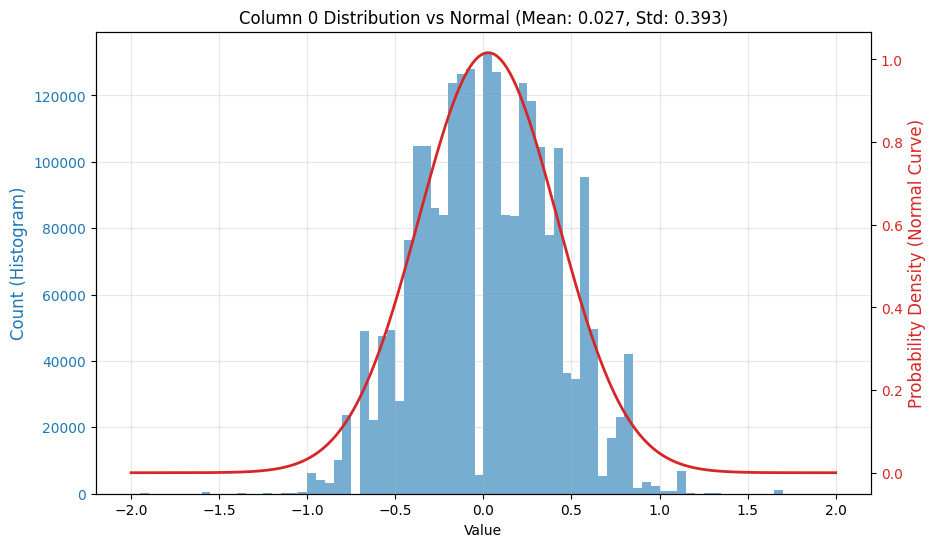

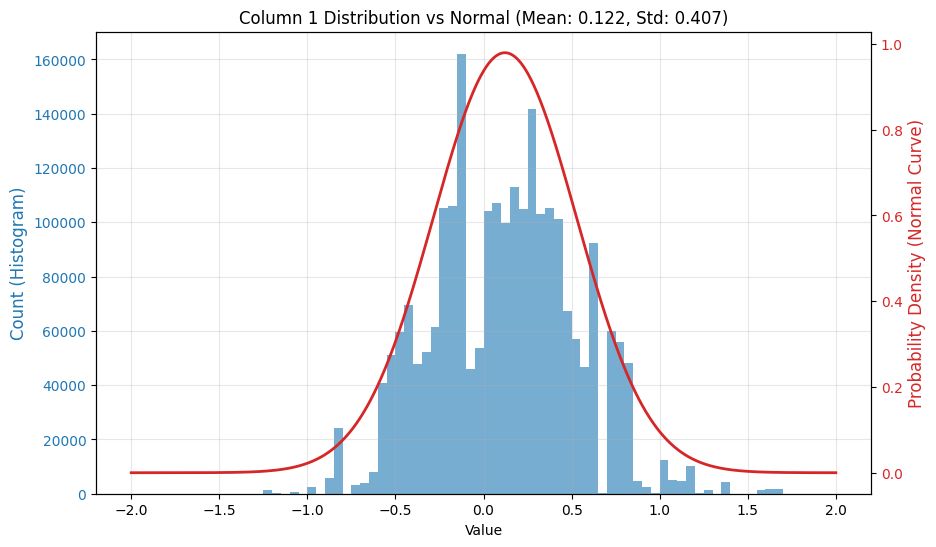

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm  # Import for generating the normal curve

type_idxs = df.filter(pl.col('type_id') == 1)['index'].to_numpy()
print(type_idxs.shape)

type_diff = diff[type_idxs].reshape(-1, 2)
type_diff = type_diff[(np.abs(type_diff[:, 0]) < 2) & (np.abs(type_diff[:, 1]) < 2)]

print(type_diff.shape)

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ... (Assuming data 'type_diff' is already prepared as per your previous code) ...

# Calculate stats
medians = np.median(type_diff, axis = 0)
means = np.mean(type_diff, axis=0)
stds = np.std(type_diff, axis=0)
x_axis = np.linspace(-2, 2, 1000)

print('MEDIAN:', medians)
print('MEANS:', means)
print('STDS:', stds)

# Define a helper function to plot dual axes
def plot_dual_axis(data, mean, std, col_index):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Left Y-Axis: Histogram (Counts) ---
    color = 'tab:blue'
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Count (Histogram)', color=color, fontsize=12)
    ax1.hist(data, bins=np.arange(-2, 2, 0.05), color=color, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # --- Right Y-Axis: Normal Distribution (Density) ---
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Probability Density (Normal Curve)', color=color, fontsize=12)
    ax2.plot(x_axis, norm.pdf(x_axis, mean, std), color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"Column {col_index} Distribution vs Normal (Mean: {mean:.3f}, Std: {std:.3f})")
    plt.show()

# Plot for Column 0
plot_dual_axis(type_diff[:, 0], means[0], stds[0], 0)

# Plot for Column 1
plot_dual_axis(type_diff[:, 1], means[1], stds[1], 1)

In [52]:
pred_kpt_xys1 = np.load('/home/dangnh36/datasets/ecg/processed/pseudo_label/round1_finetune_dsnt/keypoints_by_round1.npy')
pred_kpt_xys2 = np.load('/home/dangnh36/datasets/ecg/processed/pseudo_label/round2_finetune_dsnt/keypoints_by_round2.npy')
pred_kpt_xys1.shape, pred_kpt_xys2.shape

((8793, 2422, 2), (8793, 2422, 2))

In [55]:
pred_kpt_xys2[1]

array([[  71.30957031,   16.13574219],
       [ 108.78613281,   17.17675781],
       [ 147.30371094,   17.17675781],
       ...,
       [ 150.09651619, 1530.50717701],
       [ 406.49699992, 1599.75936705],
       [ 783.31533313, 1600.21938615]])

In [61]:
21296646 - 8793 * 2422

0

(21296646, 2)


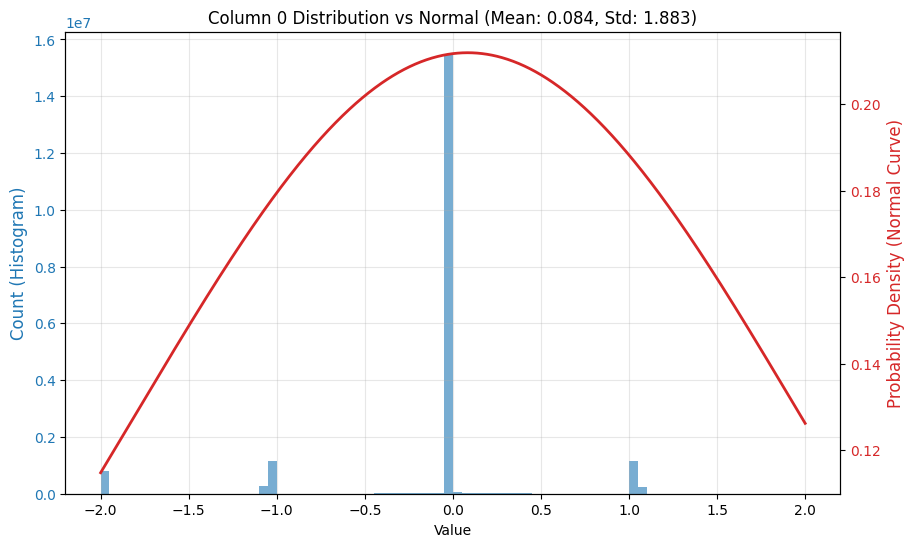

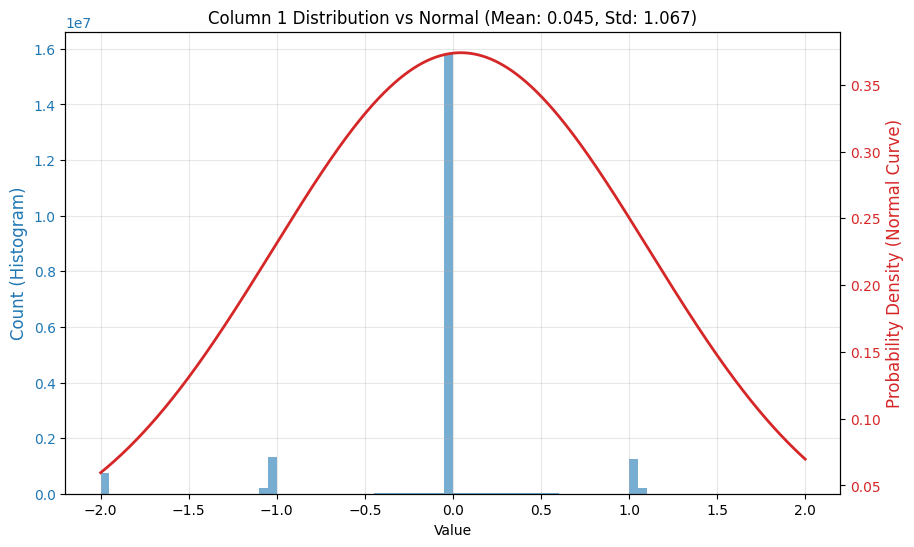

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm  # Import for generating the normal curve

type_diff = pred_kpt_xys2 - pred_kpt_xys1
type_diff = type_diff.reshape(-1, 2)
# type_diff = type_diff[(np.abs(type_diff[:, 0]) < 5) & (np.abs(type_diff[:, 1]) < 5)]

print(type_diff.shape)

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ... (Assuming data 'type_diff' is already prepared as per your previous code) ...

# Calculate stats
means = np.mean(type_diff, axis=0)
stds = np.std(type_diff, axis=0)
x_axis = np.linspace(-2, 2, 1000)

# Define a helper function to plot dual axes
def plot_dual_axis(data, mean, std, col_index):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Left Y-Axis: Histogram (Counts) ---
    color = 'tab:blue'
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Count (Histogram)', color=color, fontsize=12)
    ax1.hist(data, bins=np.arange(-2, 2, 0.05), color=color, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # --- Right Y-Axis: Normal Distribution (Density) ---
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Probability Density (Normal Curve)', color=color, fontsize=12)
    ax2.plot(x_axis, norm.pdf(x_axis, mean, std), color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"Column {col_index} Distribution vs Normal (Mean: {mean:.3f}, Std: {std:.3f})")
    plt.show()

# Plot for Column 0
plot_dual_axis(type_diff[:, 0], means[0], stds[0], 0)

# Plot for Column 1
plot_dual_axis(type_diff[:, 1], means[1], stds[1], 1)

In [62]:
type_diff[1234:1234 + 100]

array([[-1.07421875,  0.        ],
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [-1.07421875,  0.        ],
       [ 0.        ,  0.        ],
       [-1.07421875, -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        ,  1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        , -1.07421875],
       [ 0.        ,  0.        ],
       [ 0.        ,